
========== Biden Dataset Interaction Network ==========
  biden <-> trump | Freq: 117007 | Sent: -0.35 (Neg)
  biden <-> vote | Freq: 51417 | Sent: -0.25 (Neg)
  trump <-> vote | Freq: 27506 | Sent: -0.39 (Neg)
  biden <-> democracy | Freq: 3470 | Sent: -0.19 (Neg)
  biden <-> justice | Freq: 1934 | Sent: -0.34 (Neg)
  trump <-> democracy | Freq: 1679 | Sent: -0.43 (Neg)
  biden <-> future | Freq: 1590 | Sent: -0.04 (Neu)
  vote <-> democracy | Freq: 1533 | Sent: -0.31 (Neg)
  biden <-> economy | Freq: 1333 | Sent: -0.40 (Neg)
  biden <-> climate | Freq: 1294 | Sent: -0.15 (Neg)
  trump <-> justice | Freq: 1278 | Sent: -0.40 (Neg)
  biden <-> jobs | Freq: 1101 | Sent: -0.49 (Neg)
  vote <-> justice | Freq: 1005 | Sent: -0.33 (Neg)
  biden <-> healthcare | Freq: 929 | Sent: -0.41 (Neg)
  biden <-> rights | Freq: 890 | Sent: -0.32 (Neg)
  biden <-> trust | Freq: 883 | Sent: -0.40 (Neg)
  trump <-> economy | Freq: 776 | Sent: -0.47 (Neg)
  trump <-> future | Freq: 626 | Sent: -0.33 (Neg)

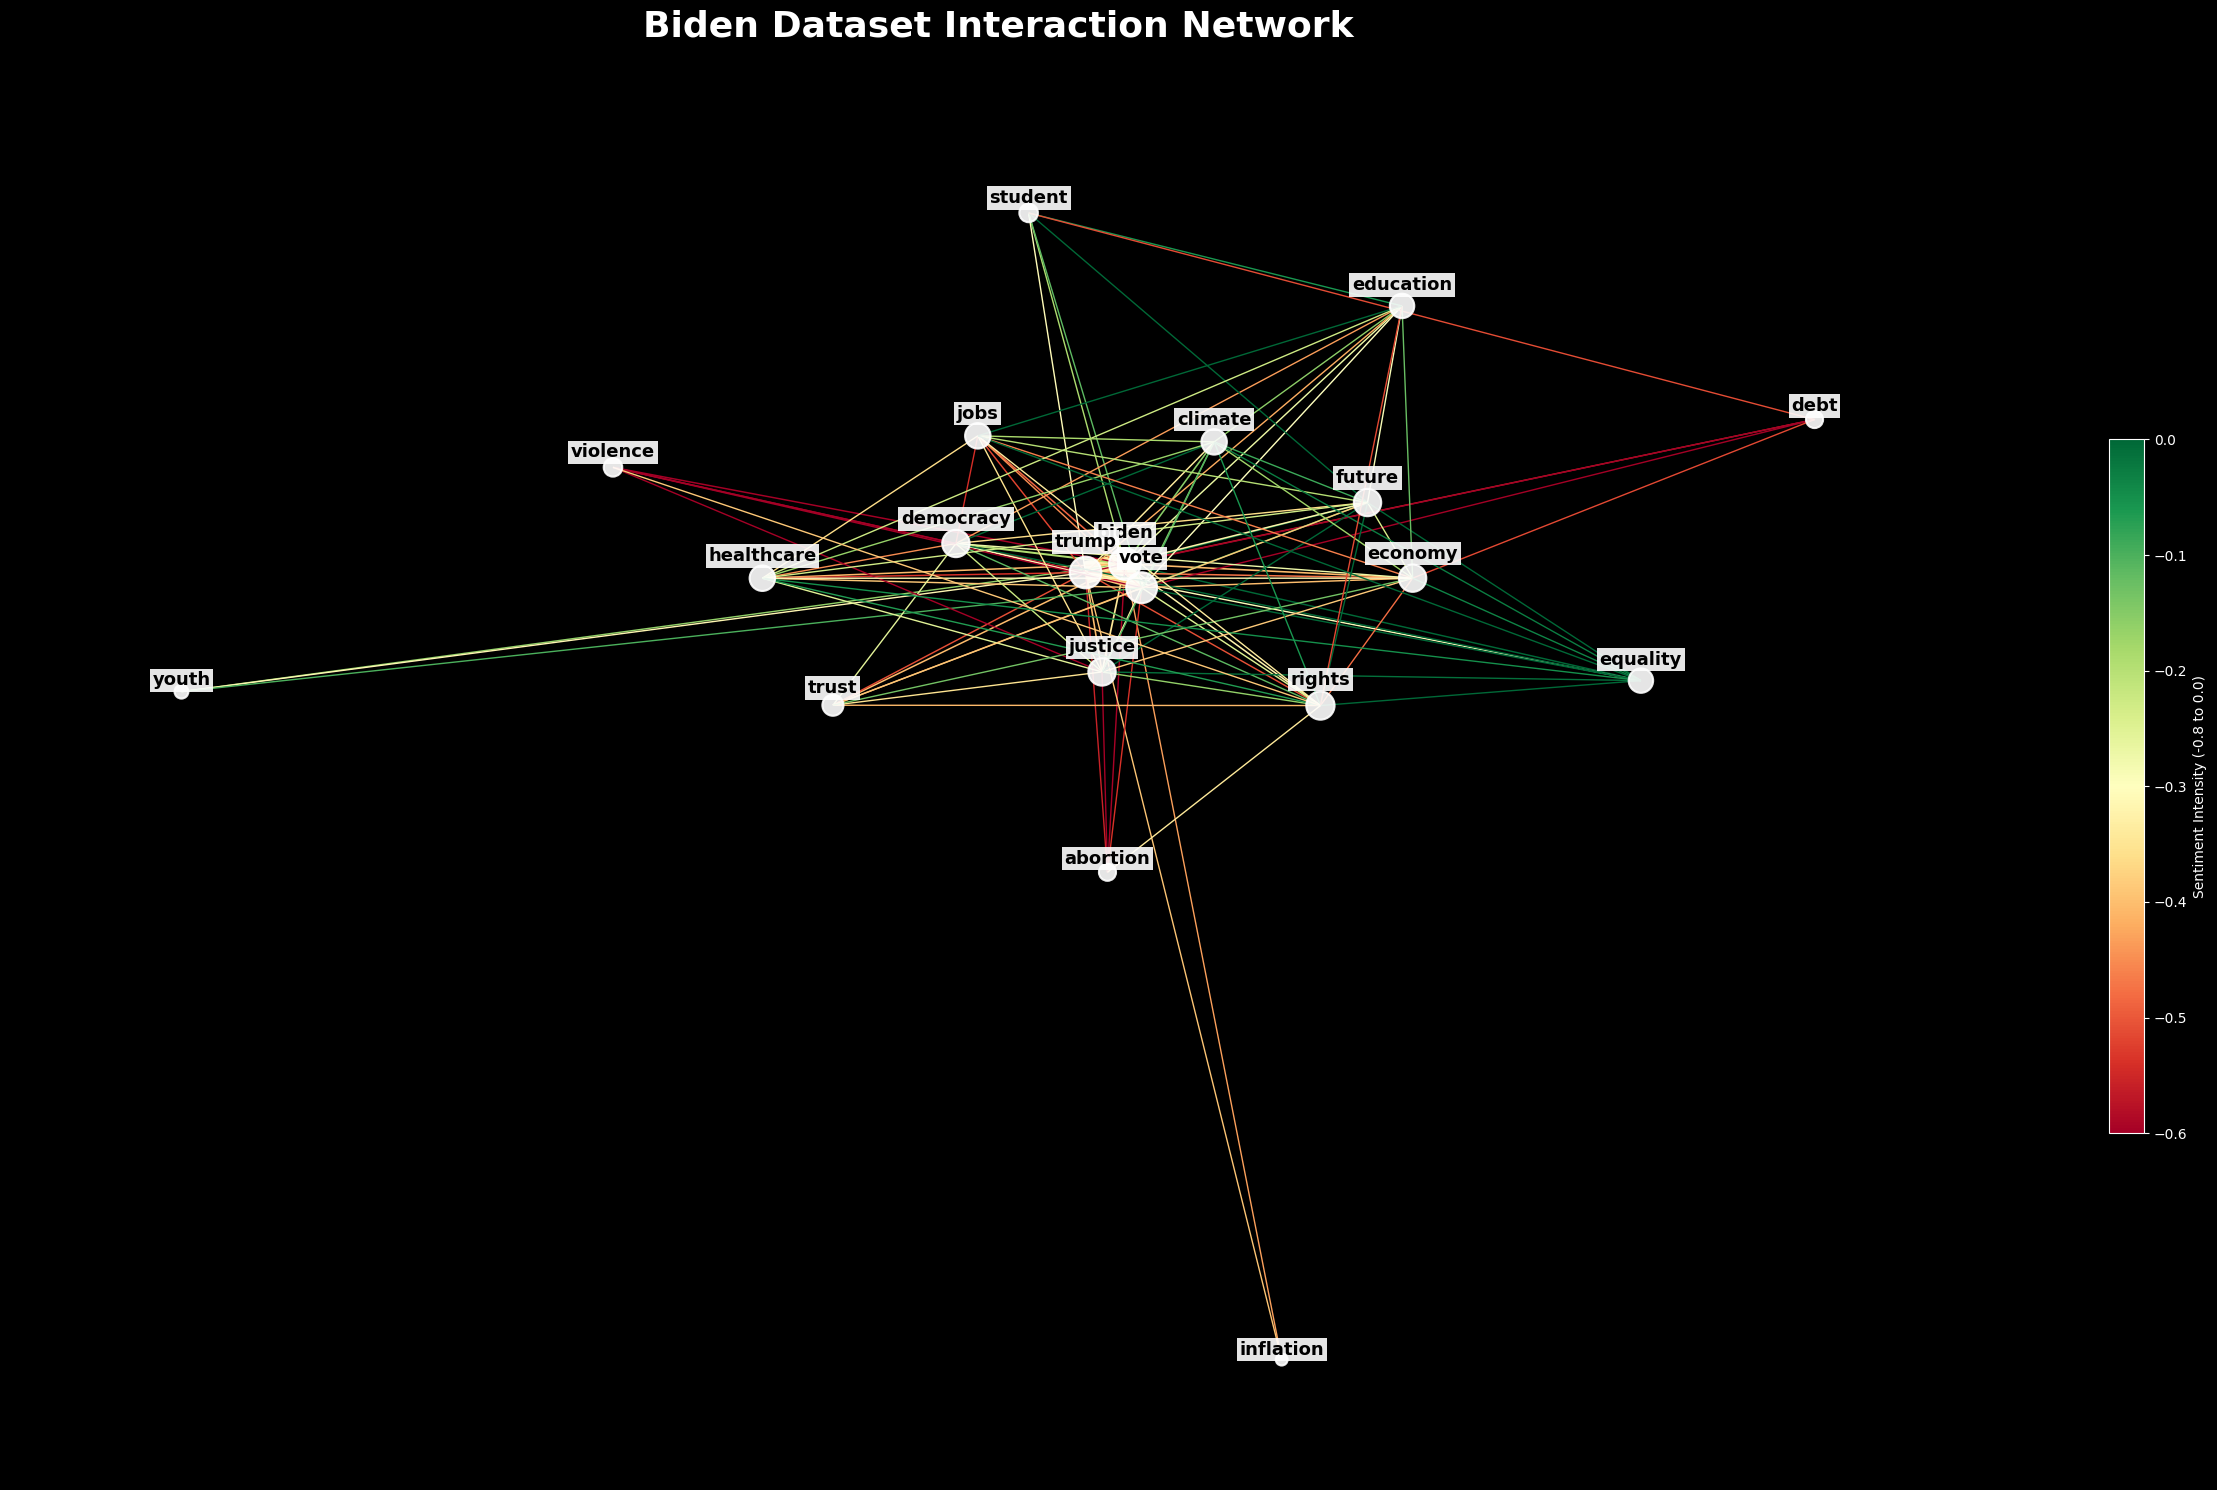


========== Trump Dataset Interaction Network ==========
  biden <-> trump | Freq: 111556 | Sent: -0.37 (Neg)
  trump <-> vote | Freq: 57585 | Sent: -0.46 (Neg)
  biden <-> vote | Freq: 27418 | Sent: -0.44 (Neg)
  trump <-> democracy | Freq: 4293 | Sent: -0.60 (Neg)
  trump <-> economy | Freq: 1959 | Sent: -0.51 (Neg)
  trump <-> justice | Freq: 1878 | Sent: -0.49 (Neg)
  vote <-> democracy | Freq: 1659 | Sent: -0.57 (Neg)
  biden <-> democracy | Freq: 1540 | Sent: -0.46 (Neg)
  trump <-> climate | Freq: 1540 | Sent: -0.57 (Neg)
  trump <-> violence | Freq: 1485 | Sent: -0.81 (Neg)
  trump <-> future | Freq: 1482 | Sent: -0.34 (Neg)
  trump <-> healthcare | Freq: 1459 | Sent: -0.61 (Neg)
  trump <-> trust | Freq: 1344 | Sent: -0.56 (Neg)
  trump <-> jobs | Freq: 1281 | Sent: -0.53 (Neg)
  trump <-> rights | Freq: 1262 | Sent: -0.60 (Neg)
  trump <-> debt | Freq: 913 | Sent: -0.70 (Neg)
  biden <-> economy | Freq: 704 | Sent: -0.46 (Neg)
  biden <-> violence | Freq: 629 | Sent: -0.80 (N

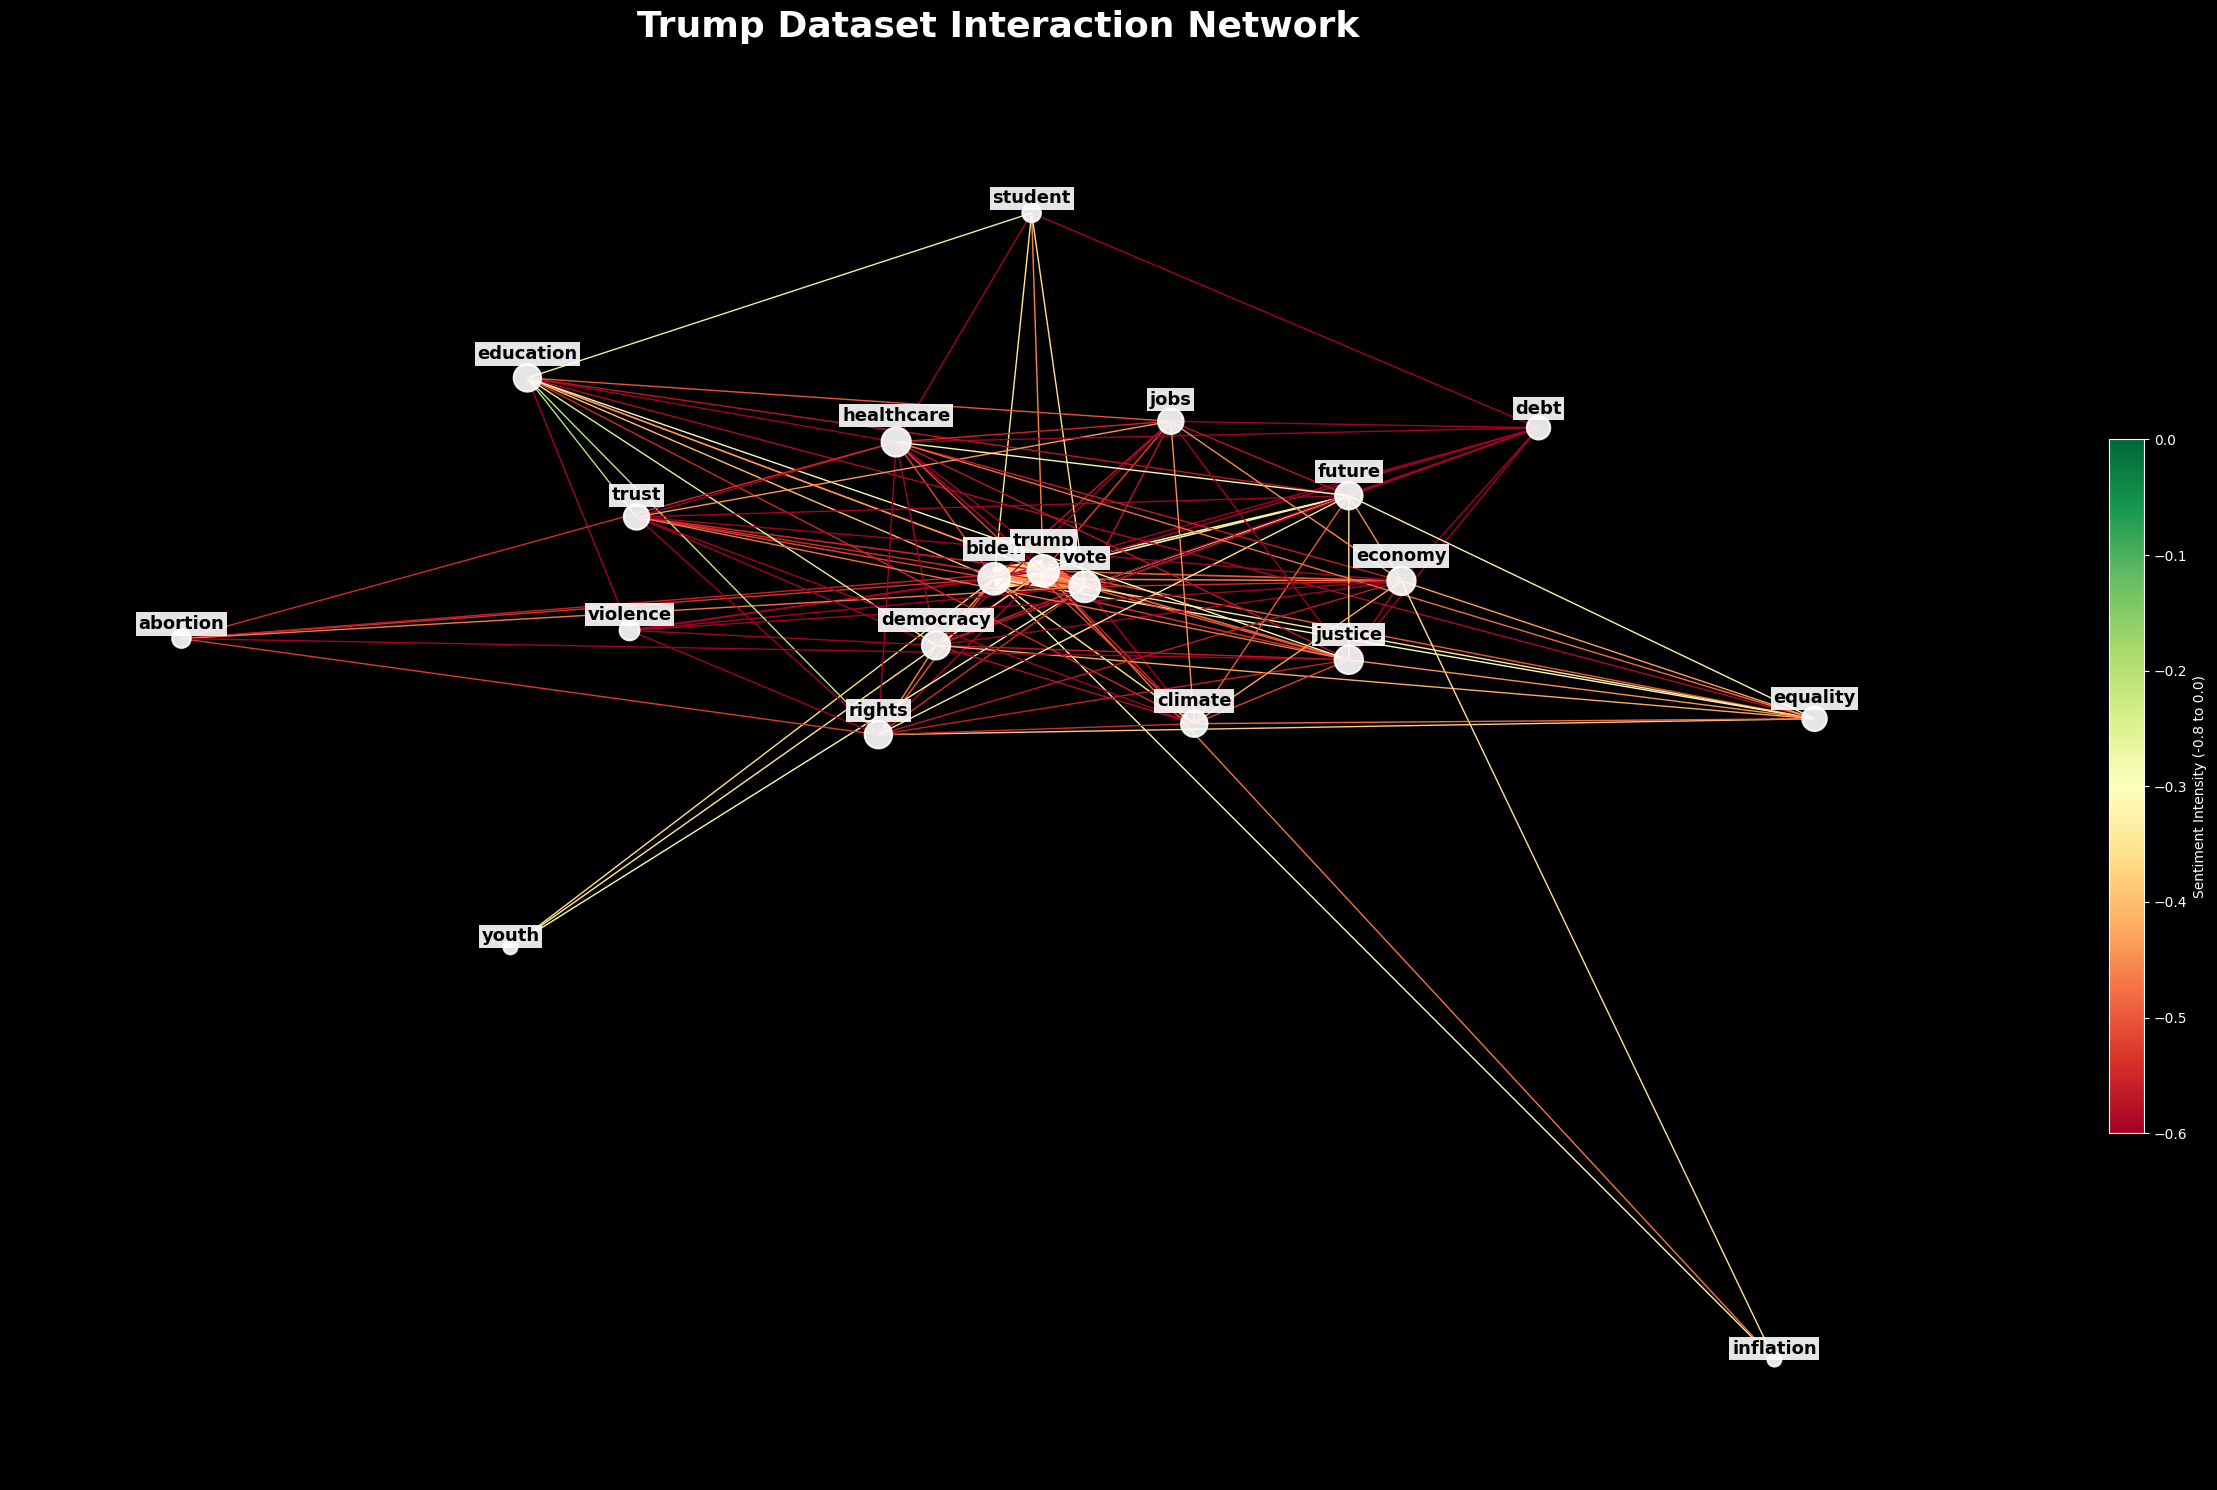


========== Full Combined Interaction Network ==========
  biden <-> trump | Freq: 228563 | Sent: -0.36 (Neg)
  trump <-> vote | Freq: 85091 | Sent: -0.44 (Neg)
  biden <-> vote | Freq: 78835 | Sent: -0.32 (Neg)
  trump <-> democracy | Freq: 5972 | Sent: -0.55 (Neg)
  biden <-> democracy | Freq: 5010 | Sent: -0.27 (Neg)
  vote <-> democracy | Freq: 3192 | Sent: -0.44 (Neg)
  trump <-> justice | Freq: 3156 | Sent: -0.46 (Neg)
  trump <-> economy | Freq: 2735 | Sent: -0.50 (Neg)
  biden <-> justice | Freq: 2464 | Sent: -0.39 (Neg)
  biden <-> future | Freq: 2200 | Sent: -0.11 (Neg)
  trump <-> future | Freq: 2108 | Sent: -0.33 (Neg)
  trump <-> climate | Freq: 2042 | Sent: -0.51 (Neg)
  biden <-> economy | Freq: 2037 | Sent: -0.42 (Neg)
  trump <-> healthcare | Freq: 1948 | Sent: -0.59 (Neg)
  biden <-> climate | Freq: 1782 | Sent: -0.21 (Neg)
  trump <-> jobs | Freq: 1776 | Sent: -0.53 (Neg)
  trump <-> violence | Freq: 1773 | Sent: -0.80 (Neg)
  trump <-> trust | Freq: 1744 | Sent: -0.

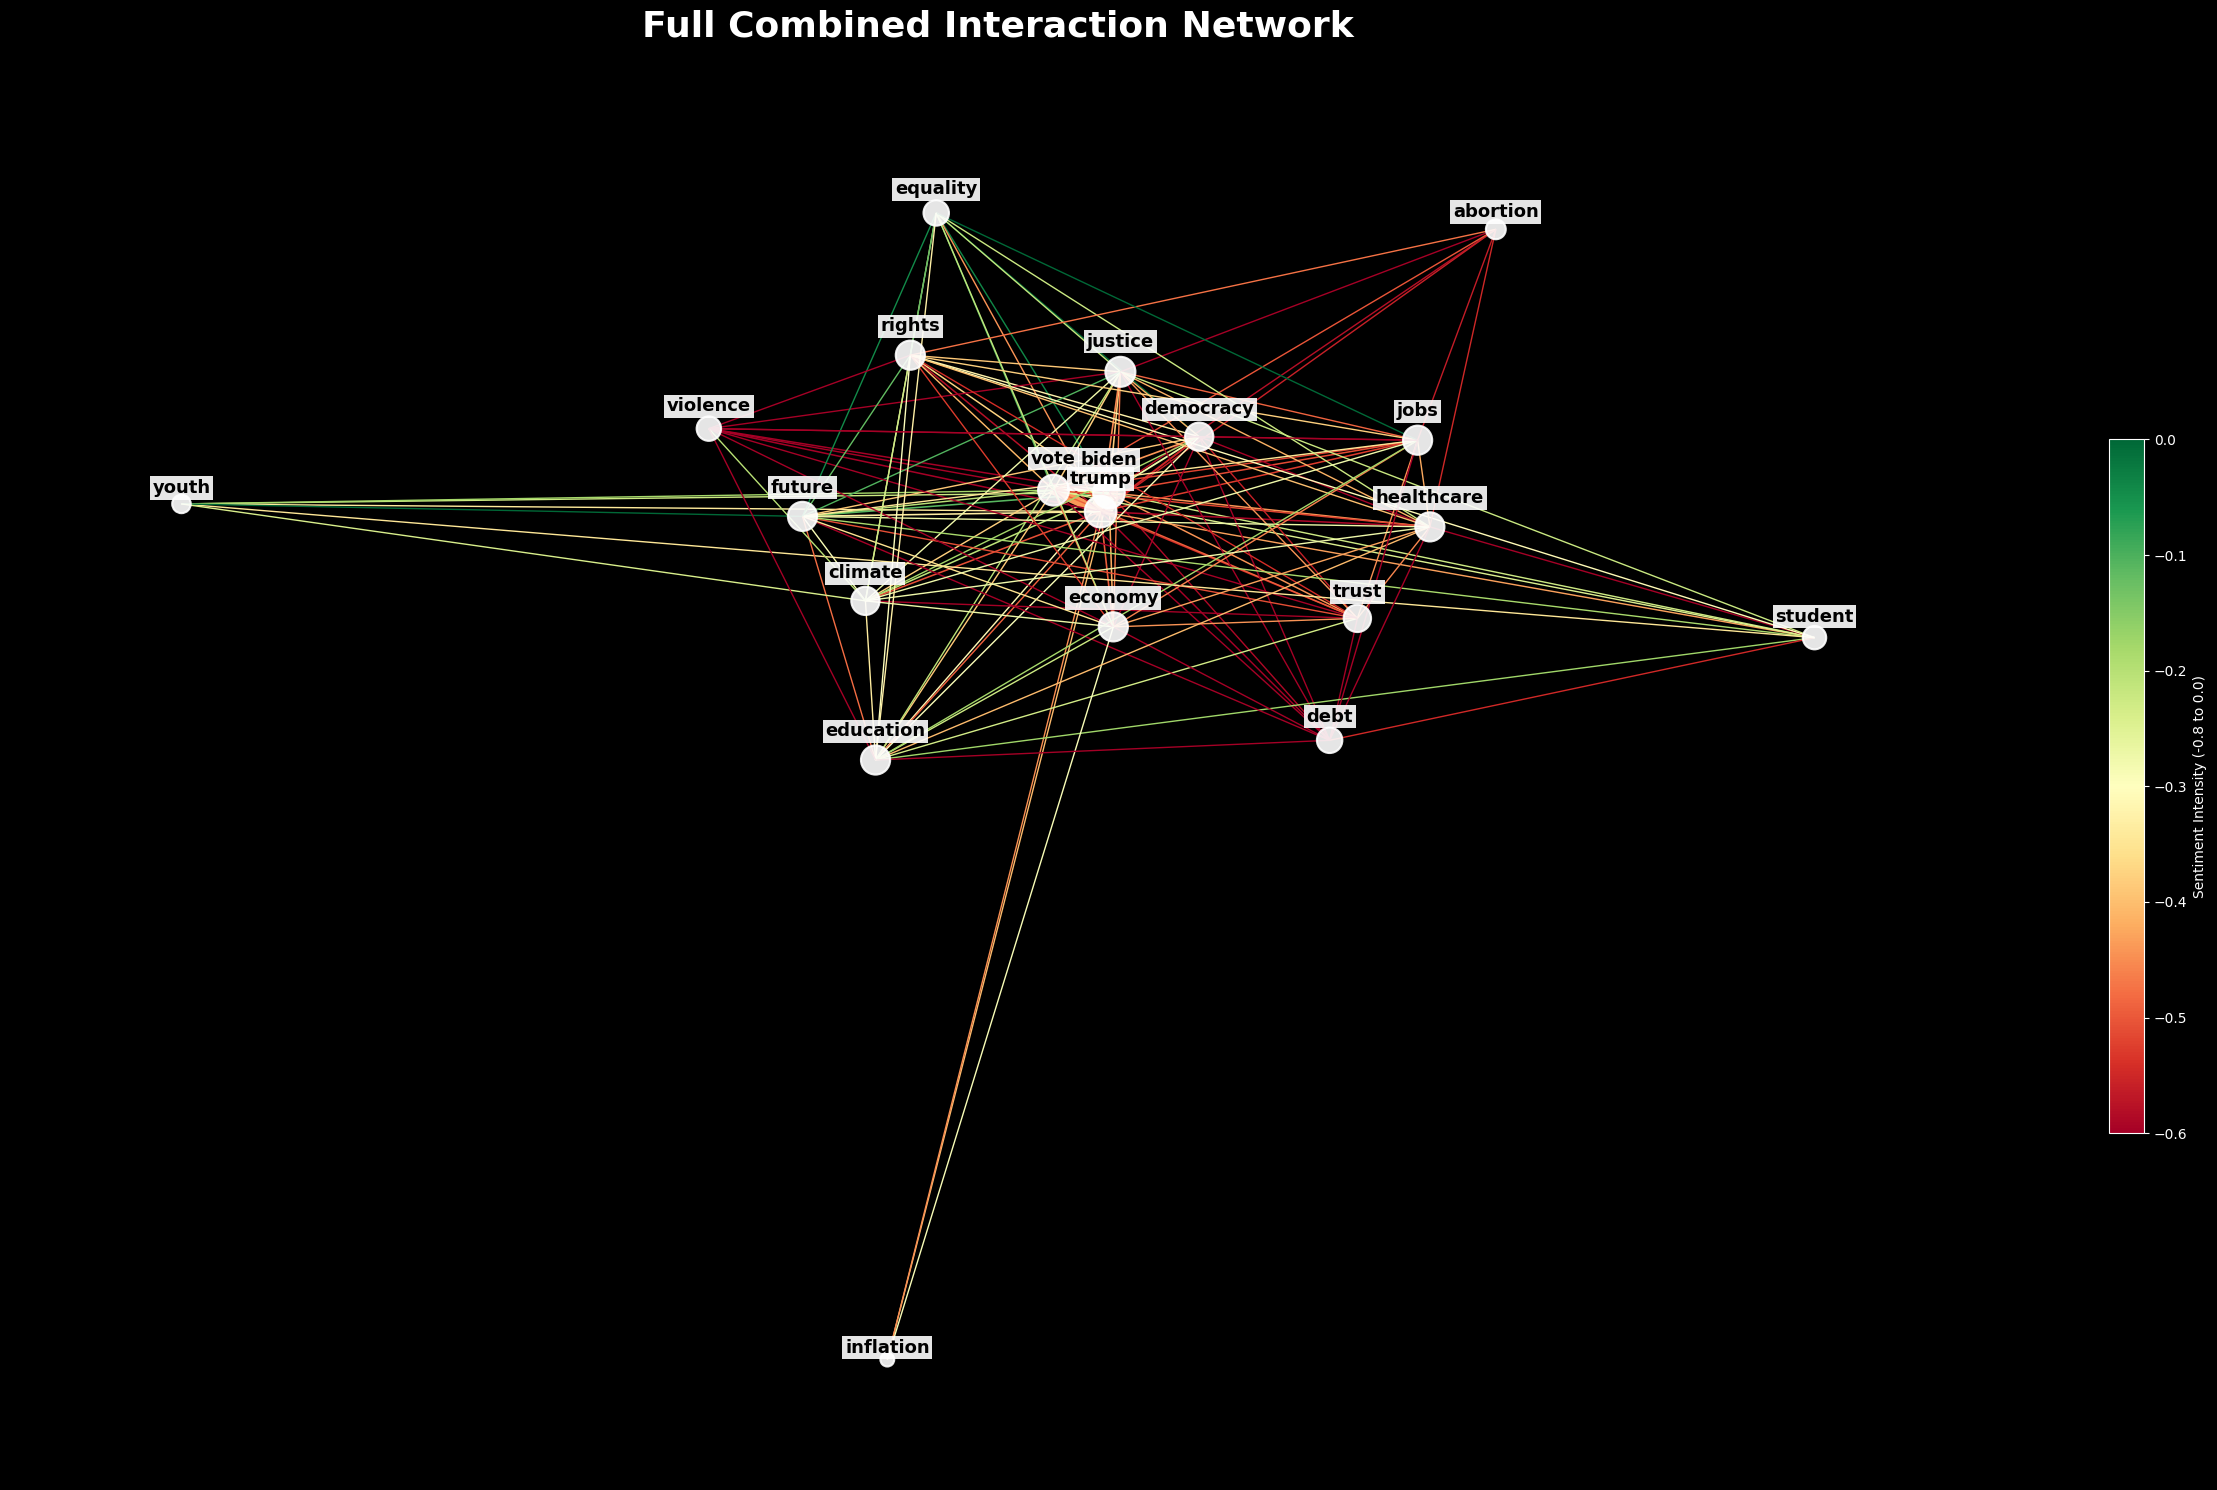

In [21]:

import pandas as pd
import networkx as nx
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. SETUP & DATA LOADING
# Ensure your CSVs have 'tweet', 'keywords', and 'sentiment' columns
biden_df = pd.read_csv('translated_data/biden_translated.csv')
trump_df = pd.read_csv('translated_data/trump_translated.csv')
combined_df = pd.concat([biden_df, trump_df])


SENTIMENT_COL = 'sentiment_score'

political_keywords = [
    'vote', 'youth', 'student','biden', 'trump', 'democracy', 'climate', 
    'debt', 'healthcare','economy', 'inflation', 'abortion', 'rights', 
    'future', 'violence', 'trust', 'justice', 'equality', 'education', 'jobs'
]

def extract_keywords(text):
    if not isinstance(text, str): return []
    text = text.lower()
    found = [word for word in political_keywords if word in text]
    return list(set(found))

# Pre-process
biden_df['keywords'] = biden_df['tweet'].apply(extract_keywords)
trump_df['keywords'] = trump_df['tweet'].apply(extract_keywords)
combined_df['keywords'] = combined_df['tweet'].apply(extract_keywords)

def generate_fixed_network(df, title, threshold=5, top_n=20):
    # 1. Standard Data Processing
    pair_data = {}
    for _, row in df.iterrows():
        tags = row['keywords']
        score = row.get('sentiment_score', 0)
        if len(tags) > 1:
            for pair in combinations(sorted(tags), 2):
                if pair not in pair_data: pair_data[pair] = []
                pair_data[pair].append(score)

    G = nx.Graph()
    for (tag1, tag2), scores in pair_data.items():
        if len(scores) > threshold:
            avg_s = sum(scores) / len(scores)
            G.add_edge(tag1, tag2, weight=len(scores), sentiment=avg_s)

    # 3. Print Analysis
    print(f"\n{'='*10} {title} {'='*10}")
    edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
    for u, v, data in edges_sorted[:top_n]:
        sentiment_label = "Pos" if data['sentiment'] > 0.05 else "Neg" if data['sentiment'] < -0.05 else "Neu"
        print(f"  {u} <-> {v} | Freq: {data['weight']} | Sent: {data['sentiment']:.2f} ({sentiment_label})")

    # 2. Layout & Centrality
    # We use a very high k to give those big nodes plenty of room
    pos = nx.spring_layout(G, k=10.0, iterations=150)
    centrality = nx.degree_centrality(G)
    
    # Scale nodes: Influence is still visible (Base 100 + centrality * 5000)
    node_sizes = [20 + (centrality[node] * 500) for node in G.nodes()]

    plt.style.use('dark_background')
    plt.figure(figsize=(25, 15))
    
    # 3. Draw EdGES (Frequency = Width, Sentiment = Color)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [1 + (w / max_w) * 15 for w in weights]
    edge_colors = [G[u][v]['sentiment'] for u, v in G.edges()]
    
    # Using 'turbo' for that dark rainbow look
    edges = nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, 
                                   edge_cmap=plt.cm.RdYlGn, edge_vmin=-0.6, edge_vmax=0.0, alpha=1.0)

    # 4. Draw NODES (Uniform color to reduce visual noise)
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#ffffff",
                           edgecolors='white', linewidths=1.5, alpha=0.9)

    # 5. THE FIX: Smart Label Offsetting
    # We move the label UP based on how big the node is so it doesn't overlap
    label_pos = {}
    for node, coords in pos.items():
        # Shift Y coordinate based on that node's specific centrality
        # This keeps labels from drowning in big nodes
        shift = 0.01 + (centrality[node] * 0.03) 
        label_pos[node] = (coords[0], coords[1] + shift)
    
    # Draw labels with a semi-transparent box so they stand out from the lines
    nx.draw_networkx_labels(G, label_pos, font_size=13, font_weight='bold',
                            bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2))

    # Colorbar & Formatting
    plt.colorbar(edges, label="Sentiment Intensity (-0.8 to 0.0)", shrink=0.5)
    plt.title(title, fontsize=26, fontweight='bold', pad=40)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run it

# 3. RUNNING THE ANALYSIS
# Biden Network
generate_fixed_network(biden_df, "Biden Dataset Interaction Network")

# Trump Network
generate_fixed_network(trump_df, "Trump Dataset Interaction Network")

# Combined Network
generate_fixed_network(combined_df, "Full Combined Interaction Network")